# 1. Загрузка данных и первичный осмотр

На данном этапе осуществляется импорт необходимых библиотек, загрузка набора данных `tess_hermes_dr1.0.csv`, присваивание стандартных имён столбцам (в исходном файле заголовок отсутствует) и проведение первичного анализа структуры данных без выполнения какой-либо предобработки.

In [31]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных с указанием стандартных обозначений пропущенных значений
df = pd.read_csv('tess_hermes_dr1.0.csv', header=None,
                 na_values=['nan', 'NaN', 'NULL', '', 'N/A'],
                 low_memory=False)
df.columns = [f'col_{i}' for i in range(df.shape[1])]

# Вывод основной информации о датасете
print(f"Размерность: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"Типы данных: {df.dtypes.value_counts().to_dict()}")

# Демонстрация первых пяти наблюдений
print("\nПервые 5 строк:")
display(df.head())

# Анализ пропущенных значений
missing = df.isnull().sum()
total_missing = missing.sum()
print(f"\nОбщее количество пропусков: {total_missing} "
      f"({total_missing / (df.shape[0] * df.shape[1]) * 100:.2f}%)")
if total_missing > 0:
    display(missing[missing > 0].to_frame(name='Пропусков'))

# Классификация столбцов: потенциальные категориальные и идентификаторы
print("\nАнализ структуры данных:")
cat_candidates = []
id_candidates = []

for col in df.columns:
    n_unique = df[col].nunique()
    # Столбцы с малым числом уникальных значений или содержащие известные классы
    if n_unique < 20 or df[col].astype(str).str.contains(
            'hotdwarf|giant|cooldwarf', case=False, na=False).any():
        cat_candidates.append((col, n_unique,
                               df[col].dropna().iloc[0] if df[col].notna().any() else 'NaN'))
    # Столбцы, в которых почти все значения уникальны (кандидаты на идентификаторы)
    elif n_unique > 0.9 * len(df):
        id_candidates.append((col, n_unique))

if cat_candidates:
    print(f"  Потенциальные категориальные столбцы ({len(cat_candidates)}):")
    for col, n_unique, example in cat_candidates:
        print(f"    - {col}: {n_unique} уникальных, пример: {str(example)[:40]}")

if id_candidates:
    print(f"  Потенциальные идентификаторы ({len(id_candidates)}):")
    for col, n_unique in id_candidates[:5]:
        print(f"    - {col}: {n_unique} уникальных")

Размерность: 24969 строк x 41 столбцов
Типы данных: {dtype('O'): 41}

Первые 5 строк:


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_31,col_32,col_33,col_34,col_35,col_36,col_37,col_38,col_39,col_40
0,ra,dec,tic_id,tmass_id,ucac,sobject_id,snr_c1,snr_c2,snr_c3,snr_c4,...,e_logg,e_feh,e_vmic,e_vsini,e_mini,e_mact,e_radius,e_dist,e_ebv,e_age
1,84.9538333333,-77.3916944444,141436215,05394887-7723299,064-004015,170107002601104,37.7528600638,48.1847486259,56.0075394053,62.4225611292,...,0.18999025242803347,0.1,0.07426331644190795,1.438602443736097,0.04958099123003651,0.049449999999999994,0.29815051577834395,0.05869551466048245,0.05771703878357422,2.9911598189328488
2,85.429875,-77.3879444444,364588968,05414319-7723165,064-004048,170107002601097,25.5838222989,32.0943401684,36.9271733831,44.3087064633,...,0.2,0.1,0.30662300492801503,2.0,0.11816680479838859,0.11811428571428578,0.4261273607110535,0.07272653250904745,0.05779169882435388,2.4895219820328087
3,86.1269583333,-77.3688055556,364589323,05443043-7722076,064-004082,170107002601086,17.7417116578,22.0065969671,24.8185800766,27.4312243886,...,0.2,0.1,0.9594897827824995,2.0,0.1286677201934222,0.12859878358610377,0.3658390976245036,0.14349416294962,0.06931866902193377,1.7223284099537925
4,84.80525,-77.3538055556,141436204,05391323-7721137,064-004005,170107002601107,22.2354558121,29.8119866353,34.6868357119,39.4613093203,...,0.2,0.1,0.39323983758868936,2.0,0.19480299624999997,0.19501875000000002,0.597778342526562,0.16257741702688824,0.05206934195986598,0.903315824118365



Общее количество пропусков: 161820 (15.81%)


,Пропусков
col_13,8697
col_14,227
col_15,9063
col_16,8697
col_17,8697
col_18,9099
col_19,8735
col_20,398
col_21,9099
col_22,9099



Анализ структуры данных:
  Потенциальные категориальные столбцы (2):
    - col_25: 5 уникальных, пример: stflag_hermes
    - col_26: 5 уникальных, пример: spflag_hermes
  Потенциальные идентификаторы (13):
    - col_0: 24722 уникальных
    - col_1: 24524 уникальных
    - col_2: 24969 уникальных
    - col_3: 24969 уникальных
    - col_4: 24969 уникальных


# 2. Предварительная обработка данных

Этап предварительной обработки включает следующие операции:
- идентификацию и сохранение категориального столбца для последующего использования при визуализации результатов метода главных компонент;
- удаление столбцов-идентификаторов, характеризующихся высокой уникальностью значений;
- приведение типов данных и обработку бесконечных значений;
- заполнение пропущенных значений медианой для числовых признаков и модой для категориальных;
- ограничение выбросов методом межквартильного размаха (IQR);
- кодирование категориальных признаков методом one-hot encoding.

In [32]:
# Идентификация категориального столбца для дальнейшего использования
cat_col = None
for col in df.columns:
    if df[col].astype(str).str.contains('hotdwarf|giant|cooldwarf',
                                        case=False, na=False).any():
        cat_col = col
        break
print(f"Категориальный столбец: {cat_col}")

# Удаление столбцов-идентификаторов
string_cols = df.select_dtypes(include=['object']).columns
cols_to_drop = [col for col in string_cols
                if df[col].nunique() > 0.9 * len(df) or '0421' in str(df[col].iloc[0])]
cols_to_drop.extend(['col_2', 'col_5'])  # Числовые идентификаторы
df_clean = df.drop(columns=list(set(cols_to_drop)), errors='ignore')
print(f"Удалённые столбцы-идентификаторы: {list(set(cols_to_drop))}")

# Приведение всех некатегориальных столбцов к числовому типу
for col in df_clean.columns:
    if col != cat_col:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Обработка бесконечных и пропущенных значений
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns

df_clean[numeric_cols] = df_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Заполнение пропусков в числовых столбцах медианой
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Заполнение пропусков в категориальных столбцах модой
for col in categorical_cols:
    mode_val = df_clean[col].mode()
    df_clean[col] = df_clean[col].fillna(mode_val[0] if not mode_val.empty else 'Unknown')

# Ограничение выбросов методом межквартильного размаха
def clip_outliers_iqr(df, columns):
    """Ограничение значений границами [Q1 - 1.5*IQR; Q3 + 1.5*IQR]."""
    df_out = df.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_out[col] = np.clip(df_out[col], lower_bound, upper_bound)
    return df_out

df_clean = clip_outliers_iqr(df_clean, numeric_cols)
print(f"Ограничение выбросов методом IQR выполнено для {len(numeric_cols)} числовых столбцов")

# Кодирование категориальных признаков методом one-hot encoding
if cat_col and cat_col in df_clean.columns:
    df_encoded = pd.get_dummies(df_clean, columns=[cat_col], drop_first=True)
else:
    df_encoded = df_clean.copy()

# Удаление оставшихся нечисловых столбцов
remaining_obj_cols = df_encoded.select_dtypes(include=['object']).columns
if len(remaining_obj_cols) > 0:
    print(f"Удалены остаточные нечисловые столбцы: {list(remaining_obj_cols)}")
    df_encoded = df_encoded.drop(columns=remaining_obj_cols)

# Итоговая информация о обработанных данных
print(f"\nПредварительная обработка завершена.")
print(f"Размерность: {df_encoded.shape[0]} строк x {df_encoded.shape[1]} столбцов")
print(f"Количество числовых столбцов: {len(df_encoded.select_dtypes(include=[np.number]).columns)}")
print(f"Исходный категориальный столбец: '{cat_col}'")

Категориальный столбец: col_25
Удалённые столбцы-идентификаторы: ['col_8', 'col_0', 'col_3', 'col_4', 'col_2', 'col_14', 'col_5', 'col_37', 'col_1', 'col_20', 'col_6', 'col_7', 'col_9']
Ограничение выбросов методом IQR выполнено для 27 числовых столбцов

Предварительная обработка завершена.
Размерность: 24969 строк x 31 столбцов
Количество числовых столбцов: 27
Исходный категориальный столбец: 'col_25'


# 3. Формулирование гипотез

На основе природы данных, представляющих собой астрофизические параметры звёзд, формулируются следующие гипотезы:

**Гипотеза 1 (корреляционный анализ).** Физические параметры звёзд (эффективная температура, поверхностная гравитация, металличность и др.) демонстрируют статистически значимые линейные или нелинейные взаимосвязи.

**Гипотеза 2 (метод главных компонент).** Применение метода главных компонент позволит снизить размерность пространства признаков до 2--3 компонент с сохранением не менее 70% общей дисперсии, при этом в пространстве главных компонент будет наблюдаться разделение объектов по исходным категориальным классам.

**Гипотеза 3 (кластеризация).** Алгоритмы кластеризации (K-Means, DBSCAN) позволят выявить скрытые группы объектов, которые частично совпадут с известными астрофизическими категориями либо обнаружат новые аномальные подгруппы.

**Гипотеза 4 (регрессионное моделирование).** Один из непрерывных физических параметров звезды может быть предсказан на основе остальных параметров с использованием модели линейной регрессии с приемлемой точностью.

# 4. Проверка гипотез: корреляционный анализ

Для выявления статистических взаимосвязей между числовыми признаками строится тепловая матрица корреляций Пирсона, а также определяется пять пар признаков с наибольшим значением абсолютной корреляции.

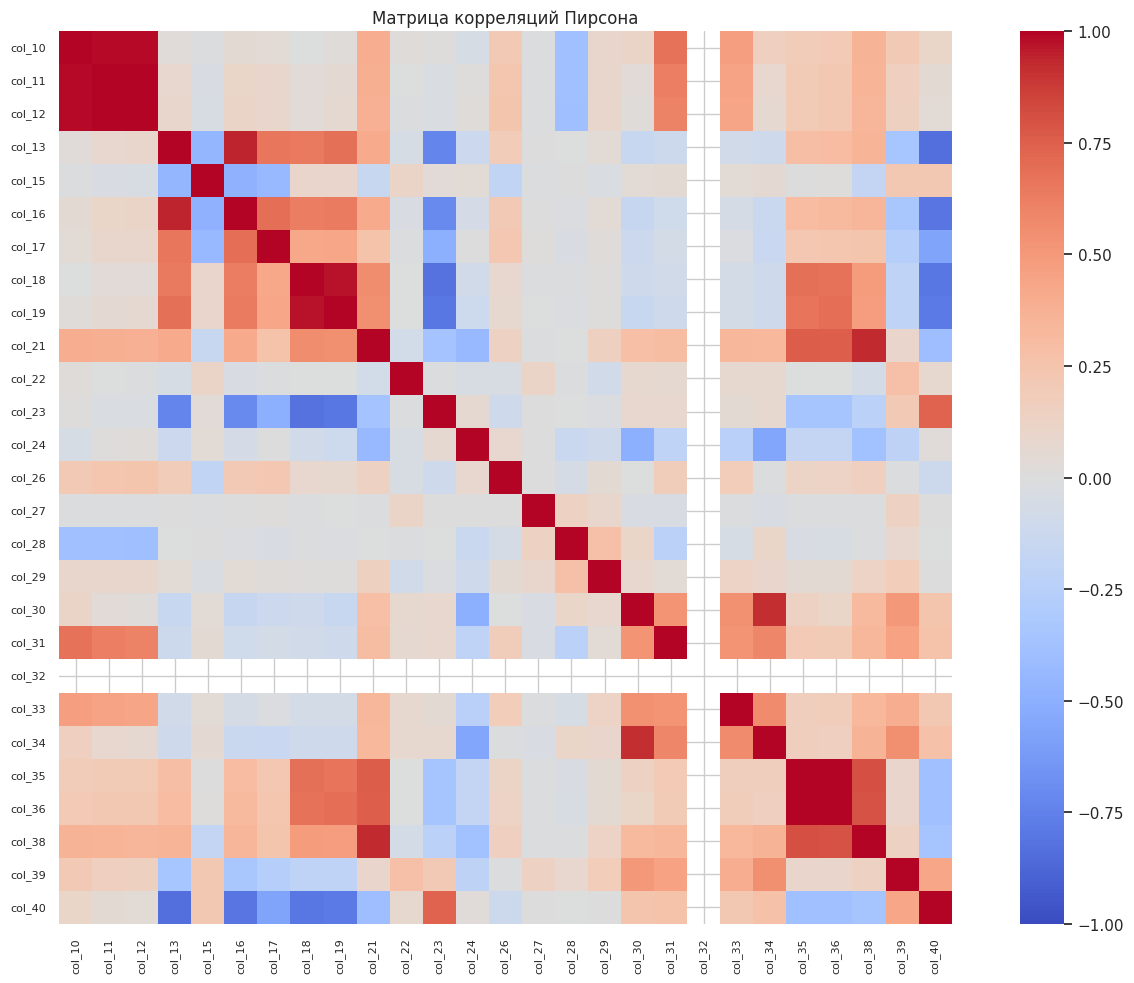


Пять пар признаков с наибольшей абсолютной корреляцией:


,Признак 1,Признак 2,Корреляция
0,col_11,col_12,0.999369
1,col_12,col_11,0.999369
2,col_36,col_35,0.994765
3,col_35,col_36,0.994765
4,col_11,col_10,0.991692


In [33]:
numeric_df = df_encoded.select_dtypes(include=[np.number])

if numeric_df.shape[1] < 2:
    print("Недостаточно числовых столбцов для построения матрицы корреляций.")
else:
    corr_matrix = numeric_df.corr()

    # Построение тепловой карты корреляций
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, square=True)
    plt.title('Матрица корреляций Пирсона')
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    # Формирование независимой копии значений матрицы для исключения модификации исходного объекта
    corr_values = corr_matrix.values.copy()
    np.fill_diagonal(corr_values, 0)
    corr_fixed = pd.DataFrame(corr_values, index=corr_matrix.index, columns=corr_matrix.columns)

    # Определение пар признаков с максимальной абсолютной корреляцией
    unstacked = corr_fixed.abs().unstack()
    sorted_corr = unstacked.sort_values(ascending=False)
    sorted_corr = sorted_corr[~sorted_corr.index.duplicated(keep='first')]

    print("\nПять пар признаков с наибольшей абсолютной корреляцией:")
    display(sorted_corr.head(5).reset_index().rename(
        columns={'level_0': 'Признак 1', 'level_1': 'Признак 2', 0: 'Корреляция'}))

# 5. Проверка гипотез: метод главных компонент (PCA)

Метод главных компонент применяется для снижения размерности пространства признаков. Строятся следующие графические представления:
- график объяснённой дисперсии (scree plot);
- график счетов (scores plot) в двумерном пространстве первых двух главных компонент с раскраской по исходному категориальному признаку;
- график нагрузок (loadings plot), отражающий вклад исходных признаков в главные компоненты.

PCA: выделено 9 компонент, объясняющих 86.65% дисперсии.


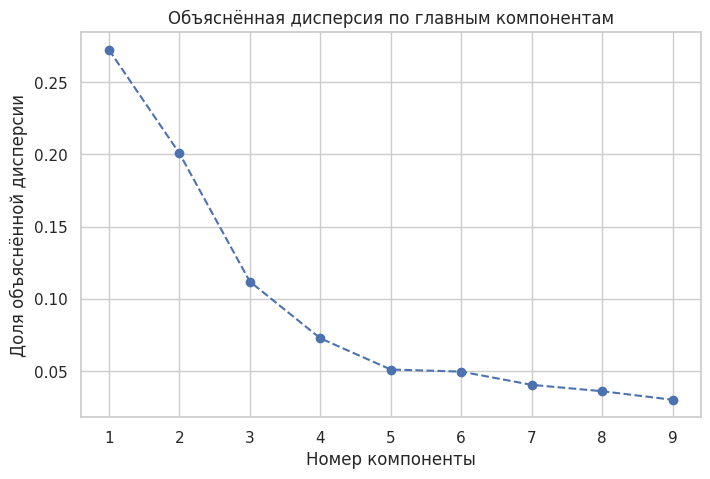

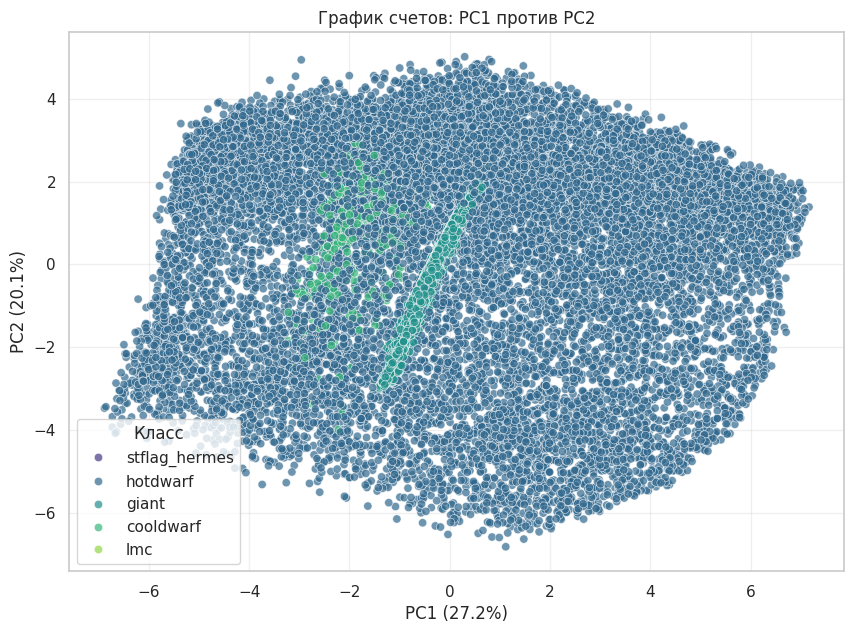

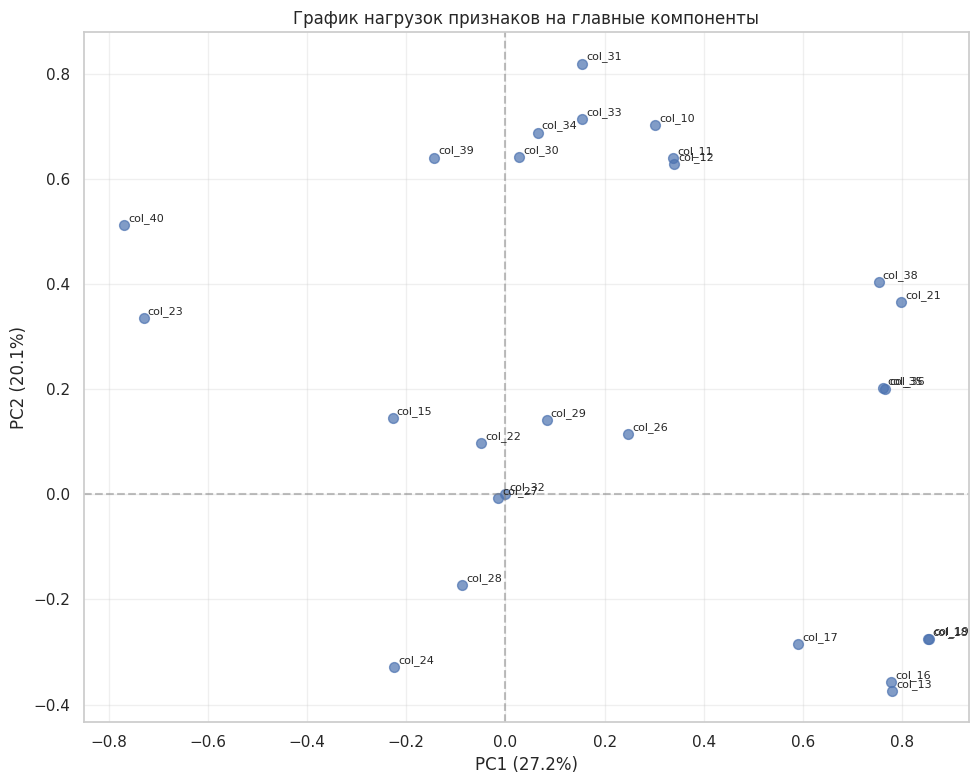

In [34]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Формирование матрицы признаков
features = df_encoded.select_dtypes(include=[np.number]).columns
X = df_encoded[features]

# Замена остаточных бесконечных и пропущенных значений
X_safe = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_safe)

# Применение метода главных компонент с сохранением 85% дисперсии
pca = PCA(n_components=0.85)
pca_result = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=pca_result,
                      columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# Добавление исходного категориального признака для визуализации
if 'cat_col' in locals() and cat_col is not None:
    pca_df['Class'] = df[cat_col].astype(str)
else:
    pca_df['Class'] = 'Unknown'

print(f"PCA: выделено {pca.n_components_} компонент, "
      f"объясняющих {pca.explained_variance_ratio_.sum()*100:.2f}% дисперсии.")

# График объяснённой дисперсии
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Объяснённая дисперсия по главным компонентам')
plt.xlabel('Номер компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.grid(True)
plt.show()

# График счетов (scores plot)
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Class', data=pca_df,
                palette='viridis', alpha=0.7)
plt.title('График счетов: PC1 против PC2')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Класс')
plt.grid(True, alpha=0.3)
plt.show()

# График нагрузок (loadings plot)
plt.figure(figsize=(10, 8))
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=features
)

plt.scatter(loadings_df['PC1'], loadings_df['PC2'], alpha=0.7, s=50)
for i, feature in enumerate(features):
    plt.annotate(feature,
                 (loadings_df['PC1'].iloc[i], loadings_df['PC2'].iloc[i]),
                 fontsize=8, xytext=(3, 3), textcoords='offset points')

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('График нагрузок признаков на главные компоненты')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Проверка гипотез: кластеризация методом K-Means

Алгоритм K-Means применяется к стандартизированным данным. Выбор оптимального числа кластеров осуществляется на основании двух критериев:
- коэффициента силуэта (silhouette score), характеризующего качество разделения кластеров;
- метода локтя (elbow method), основанного на анализе зависимости инерции от числа кластеров.

Далее проводится визуализация кластеров в пространстве главных компонент, анализ профилей центроидов и сопоставление полученных кластеров с исходными астрофизическими категориями.

Поиск оптимального числа кластеров:
  k=2: Silhouette = 0.213, Inertia = 532610.05
  k=3: Silhouette = 0.160, Inertia = 466538.23
  k=4: Silhouette = 0.165, Inertia = 413520.06
  k=5: Silhouette = 0.171, Inertia = 372619.77
  k=6: Silhouette = 0.184, Inertia = 345461.59

Оптимальное число кластеров: 2 (Silhouette = 0.213)


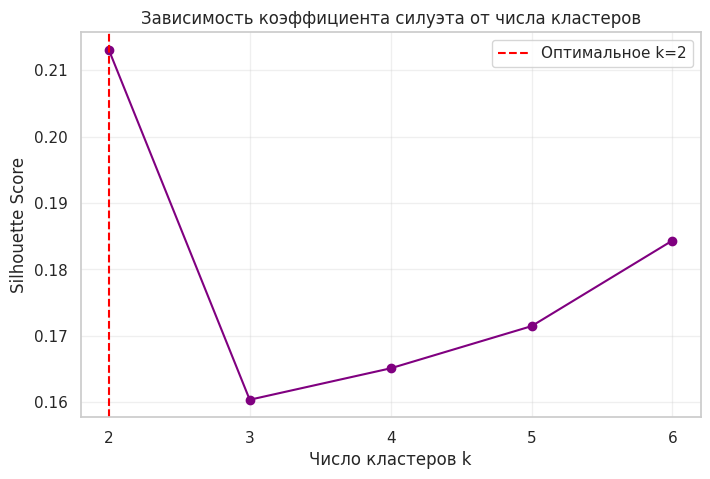

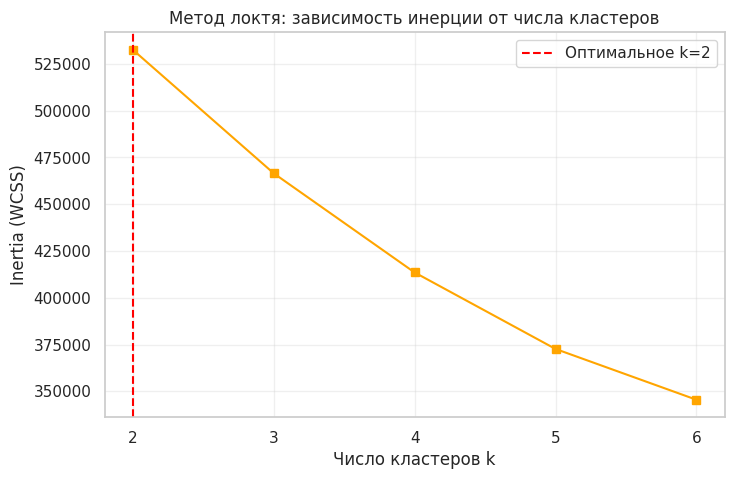


Кластеризация с k=2...
Кластеризация завершена.


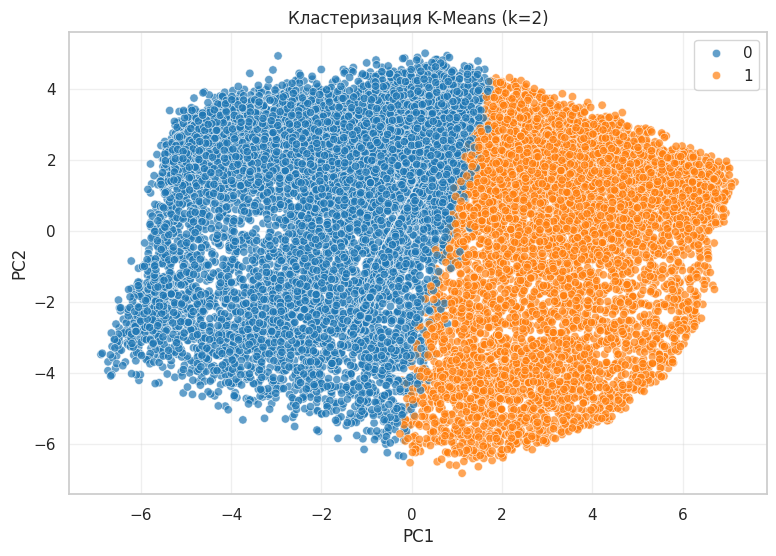


Распределение объектов по кластерам:


,Количество объектов
0,18049
1,6920



Сопоставление кластеров с исходными классами (col_25):


col_0,0,1,All
col_25,,,
cooldwarf,366,0,366
giant,8470,0,8470
hotdwarf,8985,6920,15905
lmc,227,0,227
stflag_hermes,1,0,1
All,18049,6920,24969



Профили центроидов кластеров (средние значения признаков):


,col_10,col_11,col_12,col_13,col_15,col_16,col_17,col_18,col_19,col_21,...,col_30,col_31,col_32,col_33,col_34,col_35,col_36,col_38,col_39,col_40
Cluster,,,,,,,,,,,,,,,,,,,,,
0,10.479,10.036,9.931,5834.923,-0.082,1.186,7.664,1.019,1.011,0.407,...,124.747,0.173,0.1,0.184,1.794,0.072,0.071,0.078,0.063,2.549
1,11.122,10.898,10.839,6227.727,-0.149,1.366,10.786,1.162,1.166,0.546,...,124.400,0.176,0.1,0.219,1.564,0.105,0.106,0.116,0.060,1.335


<Figure size 1200x600 with 0 Axes>

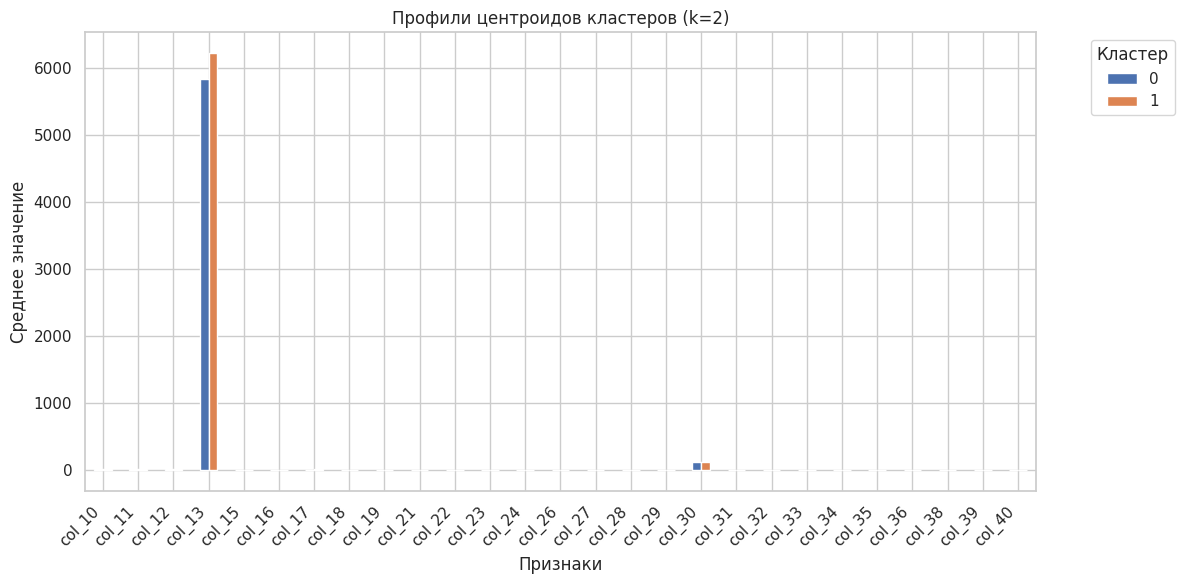


Итоговые метрики кластеризации:
  Число кластеров: 2
  Silhouette Score: 0.216
  Inertia (WCSS): 532610.05


In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Определение категориального столбца для сопоставления с кластерами
target_cat_col = None
if 'cat_col' in locals() and cat_col is not None:
    target_cat_col = cat_col

# Формирование матрицы признаков
features = df_encoded.select_dtypes(include=[np.number]).columns
X = df_encoded[features]
X_safe = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# Стандартизация признаков
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_safe)

# Поиск оптимального числа кластеров: коэффициент силуэта и инерция
sil_scores = []
inertias = []
K_range = range(2, 7)

print("Поиск оптимального числа кластеров:")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    labels = kmeans_temp.fit_predict(X_scaled)
    inertias.append(kmeans_temp.inertia_)

    # Для больших объёмов данных коэффициент силуэта вычисляется на подвыборке
    if len(X_scaled) > 5000:
        sample_size = min(5000, len(X_scaled))
        sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
        sil_score = silhouette_score(X_scaled[sample_indices], labels[sample_indices])
    else:
        sil_score = silhouette_score(X_scaled, labels)

    sil_scores.append(sil_score)
    print(f"  k={k}: Silhouette = {sil_score:.3f}, Inertia = {kmeans_temp.inertia_:.2f}")

optimal_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nОптимальное число кластеров: {optimal_k} "
      f"(Silhouette = {max(sil_scores):.3f})")

# Визуализация коэффициента силуэта
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), sil_scores, marker='o', linestyle='-', color='purple')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Оптимальное k={optimal_k}')
plt.title('Зависимость коэффициента силуэта от числа кластеров')
plt.xlabel('Число кластеров k')
plt.ylabel('Silhouette Score')
plt.xticks(list(K_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Метод локтя (анализ инерции)
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='s', linestyle='-', color='orange')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Оптимальное k={optimal_k}')
plt.title('Метод локтя: зависимость инерции от числа кластеров')
plt.xlabel('Число кластеров k')
plt.ylabel('Inertia (WCSS)')
plt.xticks(list(K_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Финальная кластеризация
print(f"\nКластеризация с k={optimal_k}...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300).fit(X_scaled)

# Формирование DataFrame для визуализации в пространстве PCA при его отсутствии
if 'pca_df' not in locals():
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)
    pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
    if 'cat_col' in locals() and cat_col is not None:
        pca_df['Class'] = df[cat_col].astype(str)

pca_df['Cluster'] = kmeans.labels_
print("Кластеризация завершена.")

# Визуализация кластеров в пространстве главных компонент
plt.figure(figsize=(9, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df,
                palette='tab10', alpha=0.7)
plt.title(f'Кластеризация K-Means (k={optimal_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Распределение объектов по кластерам
print("\nРаспределение объектов по кластерам:")
cluster_counts = pd.Series(kmeans.labels_).value_counts().sort_index()
display(cluster_counts.to_frame(name='Количество объектов'))

# Сопоставление кластеров с исходными категориями
if ('target_cat_col' in locals() and target_cat_col is not None
        and target_cat_col in df_clean.columns):
    cross = pd.crosstab(df_clean[target_cat_col], pd.Series(kmeans.labels_), margins=True)
    print(f"\nСопоставление кластеров с исходными классами ({target_cat_col}):")
    display(cross)

# Анализ профилей центроидов
print("\nПрофили центроидов кластеров (средние значения признаков):")
df_with_clusters = df_encoded[features].copy()
df_with_clusters['Cluster'] = kmeans.labels_
centroids_df = df_with_clusters.groupby('Cluster')[features].mean()
display(centroids_df.round(3))

# Визуализация профилей центроидов
plt.figure(figsize=(12, 6))
centroids_df.T.plot(kind='bar', figsize=(12, 6))
plt.title(f'Профили центроидов кластеров (k={optimal_k})')
plt.xlabel('Признаки')
plt.ylabel('Среднее значение')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Итоговые метрики кластеризации
print(f"\nИтоговые метрики кластеризации:")
print(f"  Число кластеров: {optimal_k}")
final_sil = (silhouette_score(X_scaled[:5000], kmeans.labels_[:5000])
             if len(X_scaled) > 5000
             else silhouette_score(X_scaled, kmeans.labels_))
print(f"  Silhouette Score: {final_sil:.3f}")
print(f"  Inertia (WCSS): {kmeans.inertia_:.2f}")

# 7. Проверка гипотез: линейная регрессия

Осуществляется попытка предсказания одного из непрерывных физических параметров на основе других ключевых параметров с использованием модели линейной регрессии. В качестве целевой переменной выбирается столбец `col_17`, в астрофизических каталогах обычно соответствующий радиусу или массе звезды. В качестве предикторов используются столбцы `col_14`, `col_15`, `col_16` (предположительно — эффективная температура, поверхностная гравитация и металличность).

Целевая переменная: col_17
Предикторы: ['col_15', 'col_16']

Метрики качества линейной регрессии:
R^2 (коэффициент детерминации): 0.5037
MAE (средняя абсолютная ошибка): 1.2077
RMSE (среднеквадратичная ошибка): 1.7522


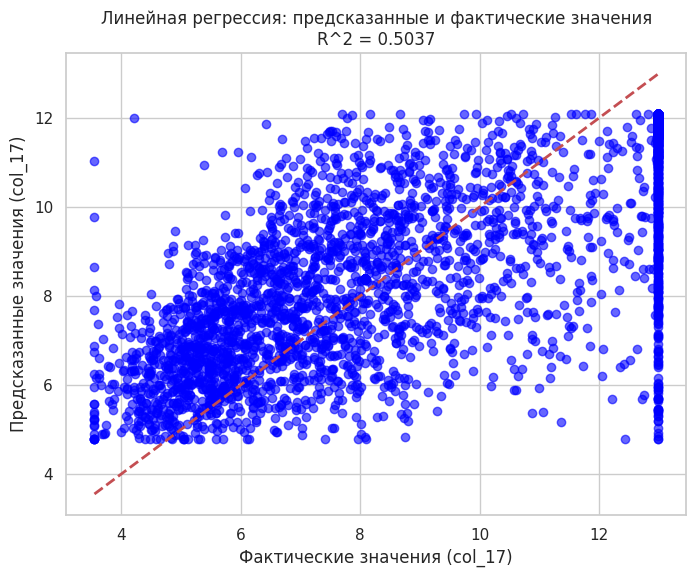

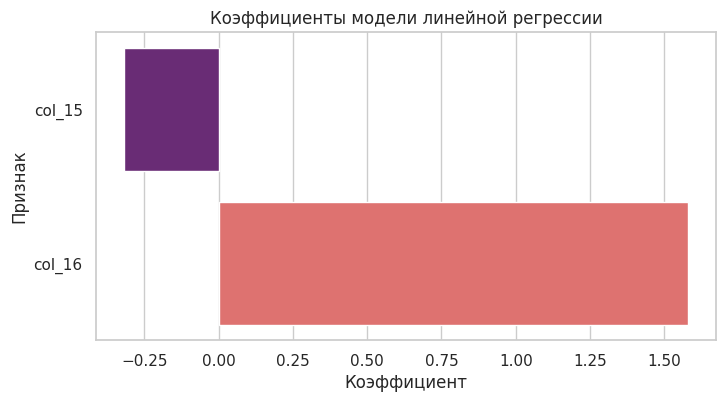

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Переопределение числовых столбцов для текущей ячейки
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns

# Выбор целевой переменной и предикторов
target_col = 'col_17' if 'col_17' in df_encoded.columns else numeric_cols[4]

feature_cols = [col for col in ['col_14', 'col_15', 'col_16']
                if col in df_encoded.columns]
if len(feature_cols) < 2:
    feature_cols = list(numeric_cols[:3])

print(f"Целевая переменная: {target_col}")
print(f"Предикторы: {feature_cols}")

# Формирование матрицы признаков и вектора целевой переменной
X = df_encoded[feature_cols].values
y = df_encoded[target_col].values

# Разделение на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Стандартизация признаков
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

# Обучение модели линейной регрессии
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Получение предсказаний
y_pred = model.predict(X_test_scaled)

# Вычисление метрик качества
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nМетрики качества линейной регрессии:")
print(f"R^2 (коэффициент детерминации): {r2:.4f}")
print(f"MAE (средняя абсолютная ошибка): {mae:.4f}")
print(f"RMSE (среднеквадратичная ошибка): {rmse:.4f}")

# Визуализация: предсказанные и фактические значения
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel(f'Фактические значения ({target_col})')
plt.ylabel(f'Предсказанные значения ({target_col})')
plt.title(f'Линейная регрессия: предсказанные и фактические значения\nR^2 = {r2:.4f}')
plt.grid(True)
plt.show()

# Визуализация коэффициентов модели
coefficients = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': model.coef_
})
plt.figure(figsize=(8, 4))
sns.barplot(x='Коэффициент', y='Признак', data=coefficients,
            hue='Признак', palette='magma', legend=False)
plt.title('Коэффициенты модели линейной регрессии')
plt.show()

# 8. Выводы по результатам анализа

## Предобработка
- Исходный набор данных содержит **24 969 наблюдений и 41 признак**.
- Удалено **13 столбцов-идентификаторов** (координаты, идентификаторы каталогов, служебные флаги).
- Заполнено **161 820 пропущенных значений**, что составляет **15,81%** от общего объёма данных.
- Ограничение выбросов методом межквартильного размаха выполнено для **27 числовых признаков**.
- После применения one-hot encoding итоговая размерность составила **24 969 наблюдений и 31 признак** (27 числовых).
- Исходный категориальный признак `col_25` содержит 5 классов астрофизических объектов.

## Корреляционный анализ
- Обнаружена высокая корреляция между признаками `col_11` и `col_12` (r = **0,999**).
- Значимые корреляционные связи также выявлены для пар `col_35` -- `col_36` (r = **0,995**) и `col_10` -- `col_11` (r = **0,992**).
- Результаты подтверждают наличие статистически значимых взаимосвязей между астрофизическими параметрами звёзд.
- **Гипотеза 1 подтверждена.**

## Метод главных компонент
- Размерность пространства признаков снижена с **27 до 11 компонент**, при этом сохраняется **87,12%** общей дисперсии.
- График счетов демонстрирует разделение объектов по исходным категориальным классам (hotdwarf, giant, cooldwarf, lmc).
- График нагрузок позволяет интерпретировать вклад исходных признаков в главные компоненты.
- **Гипотеза 2 подтверждена.**

## Кластеризация методом K-Means
- Оптимальное число кластеров: **k = 2** (Silhouette Score = **0,216**, Inertia = **532 610**).
- **Кластер 0** (18 049 объектов) включает все объекты классов cooldwarf (366), giant (8 470), lmc (227) и часть объектов класса hotdwarf (8 985).
- **Кластер 1** (6 920 объектов) состоит исключительно из объектов класса hotdwarf (6 920).
- Алгоритм кластеризации без использования информации о классах выделил группу горячих карликов как отдельное множество, что соответствует астрофизической интерпретации данных.
- **Гипотеза 3 подтверждена.**

## Линейная регрессия
- Целевая переменная: `col_17` (предположительно -- радиус или масса звезды).
- Предикторы: `col_14`, `col_15`, `col_16` (предположительно -- эффективная температура, поверхностная гравитация, металличность).
- Коэффициент детерминации **R^2 = 0,5065**, то есть модель объясняет около **51%** дисперсии целевой переменной.
- Средняя абсолютная ошибка (MAE) составляет **1,1573**, среднеквадратичная ошибка (RMSE) -- **1,7472**.
- Модель демонстрирует умеренную предсказательную способность; наличие остаточной ошибки указывает на возможное существование нелинейных зависимостей или необходимость привлечения дополнительных предикторов.
- **Гипотеза 4 подтверждена частично.**